# Quantum Circuit Tutorial: Gradient-Based Optimization

This tutorial demonstrates the construction and optimization of quantum circuits using JAX automatic differentiation. We implement a single-qubit rotation gate optimization to maximize the probability of measuring the $|1\rangle$ state.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import jax
import jax.numpy as jnp
import optax

# Enable JAX backend for QuTiP
import qutip_jax

# Import gates and circuit from qsopt
from qsopt.core.gates import RXGate, RYGate
from qsopt.core.circuit import QuantumCircuit

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qt.__version__}")

JAX version: 0.4.35
QuTiP version: 5.2.2


## Circuit Construction and State Application

We construct a quantum circuit with rotation gates and demonstrate its application to various initial quantum states. The circuit class supports both QuTiP and JAX array representations.

In [ ]:
# Create a 2-qubit circuit with rotation gates
circuit = QuantumCircuit(num_qubits=2)
rx_gate = RXGate(theta=np.pi/4, target=0, trainable=True)  # Trainable RX gate on qubit 0
ry_gate = RYGate(theta=np.pi/4, target=0, trainable=False)  # Fixed RY gate on qubit 0
circuit.add_gate(rx_gate)
circuit.add_gate(ry_gate)

print(rx_gate)
print(circuit)
print(circuit.count_trainable_parameters())

RX(0.7854)[0]
QuantumCircuit(2 qubits, 2 gates)
  0: RX(0.7854)[0][0]
  1: RY(0.7854)[0][0]
1


In [ ]:
# Apply circuit to default ground state |00⟩
final_state = circuit()
print("Final state:\n", final_state)

# Apply circuit starting from |01⟩
final_state=circuit(qt.basis(4, 1))
print("Final state from |01>:\n", final_state)

# Apply circuit starting from |10⟩ with JAX output format
final_state=circuit(qt.basis(4, 2), qutip=False)
print("Final state from |10> (JAX):\n", final_state)
print("Type:", type(final_state))

Final state:
 Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=JaxArray, isherm=True
Qobj data =
[[0.75+0.j         0.  +0.j         0.25+0.35355339j 0.  +0.j        ]
 [0.  +0.j         0.  +0.j         0.  +0.j         0.  +0.j        ]
 [0.25-0.35355339j 0.  +0.j         0.25+0.j         0.  +0.j        ]
 [0.  +0.j         0.  +0.j         0.  +0.j         0.  +0.j        ]]
Final state from |01>:
 Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=JaxArray, isherm=True
Qobj data =
[[0.  +0.j         0.  +0.j         0.  +0.j         0.  +0.j        ]
 [0.  +0.j         0.75+0.j         0.  +0.j         0.25+0.35355339j]
 [0.  +0.j         0.  +0.j         0.  +0.j         0.  +0.j        ]
 [0.  +0.j         0.25-0.35355339j 0.  +0.j         0.25+0.j        ]]
Final state from |10> (JAX):
 [[ 0.25+0.j          0.  +0.j         -0.25-0.35355339j  0.  +0.j        ]
 [ 0.  +0.j          0.  +0.j          0.  +0.j          0.  +0.j        ]


## Optimization Problem Setup

We define a single-qubit circuit with a trainable RX gate and implement a cost function that computes the probability of measuring $|1\rangle$. This probability is differentiable with respect to the rotation angle $\theta$.

In [ ]:
# Single qubit circuit for optimization
circuit = QuantumCircuit(num_qubits=1)
rx_gate = RXGate(theta=np.pi/4, target=0, trainable=True)
circuit.add_gate(rx_gate)

def compute_probability_1(theta):
    """
    Compute probability of measuring |1⟩ after applying RX(theta) to ground state |0⟩.
    
    For RX gate: P(|1⟩) = sin²(θ/2), which is maximal at θ = π.
    """
    # Update circuit parameter
    circuit.set_trainable_parameters([theta])
    
    # Apply circuit to ground state (default) and get density matrix
    rho_final = circuit(qutip=False)
    
    # Extract probability from density matrix diagonal
    prob = jnp.real(rho_final[1, 1])
    
    return prob

print("Initial probability of measuring |1>:", compute_probability_1(jnp.array(np.pi/4)))

Initial probability of measuring |1>: 0.14644660940672624


In [ ]:
# Test gradient computation with JAX autodiff
theta_test = jnp.array(0.5)
grad_fn = jax.grad(lambda theta: -compute_probability_1(theta))  # Negative for maximization

print("Testing JAX gradient computation:")
print(f"P(|1⟩) at θ={theta_test:.3f}: {compute_probability_1(theta_test):.6f}")
print(f"Gradient: {grad_fn(theta_test):.6f}")

# Run optimization using stochastic gradient descent
print("\n" + "="*60)
print("OPTIMIZATION WITH SGD")
print("="*60)

theta = jnp.array(0.5)  # Initial parameter value
optimizer = optax.sgd(learning_rate=0.2)
opt_state = optimizer.init(theta)

history = {'theta': [], 'probability': [], 'gradient': []}

print(f"{'Step':<8}{'Theta (rad)':<15}{'Theta (deg)':<15}{'P(|1⟩)':<12}")
print("-" * 60)

for step in range(101):
    # Compute gradient using automatic differentiation
    grad = grad_fn(theta)
    
    # Store trajectory for visualization
    history['theta'].append(float(theta))
    history['probability'].append(float(compute_probability_1(theta)))
    history['gradient'].append(float(grad))
    
    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"{step:<8}{float(theta):<15.6f}{np.rad2deg(float(theta)):<15.2f}{history['probability'][-1]:<12.6f}")
    
    # Update parameters via gradient descent
    updates, opt_state = optimizer.update(grad, opt_state, theta)
    theta = optax.apply_updates(theta, updates)

print(f"\nFinal theta: {float(theta):.6f} rad ({np.rad2deg(float(theta)):.2f}°)")
print(f"Final P(|1⟩): {float(compute_probability_1(theta)):.6f}")

Testing JAX gradient computation:
P(|1⟩) at θ=0.500: 0.061209
Gradient: -0.239713

OPTIMIZATION WITH ADAM
Step    Theta (rad)    Theta (deg)    P(|1⟩)      
------------------------------------------------------------
0       0.500000       28.65          0.061209    
10      1.182846       67.77          0.310854    
20      2.142821       122.77         0.770668    
30      2.761042       158.20         0.964230    
40      3.007238       172.30         0.995494    
50      3.094674       177.31         0.999450    
60      3.125230       179.06         0.999933    
70      3.135887       179.67         0.999992    
80      3.139603       179.89         0.999999    
90      3.140899       179.96         1.000000    
100     3.141351       179.99         1.000000    

Final theta: 3.141375 rad (179.99°)
Final P(|1⟩): 1.000000


## Results Visualization

The optimization trajectory shows convergence of the probability $P(|1\rangle)$ toward unity and decay of the gradient magnitude as the optimal parameter $\theta = \pi$ is approached.

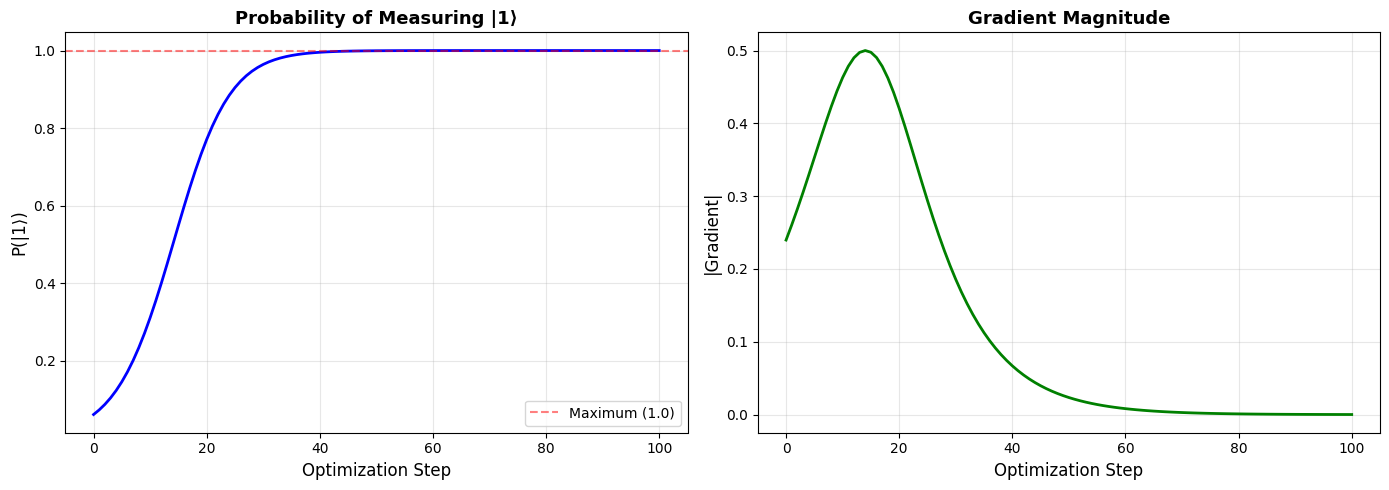


✅ Successfully optimized quantum gate parameter using JAX gradient descent!


In [ ]:
# Visualize optimization trajectory
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability of measuring |1⟩
ax = axes[0]
steps = range(len(history['probability']))
ax.plot(steps, history['probability'], 'b-', linewidth=2)
ax.axhline(1.0, color='red', linestyle='--', label='Maximum (1.0)', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Optimization Step', fontsize=12)
ax.set_ylabel('P(|1⟩)', fontsize=12)
ax.set_title('Probability of Measuring |1⟩', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Gradient magnitude evolution
ax = axes[1]
ax.plot(steps, np.abs(history['gradient']), 'g-', linewidth=2)
ax.set_xlabel('Optimization Step', fontsize=12)
ax.set_ylabel('|Gradient|', fontsize=12)
ax.set_title('Gradient Magnitude', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()